In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

In [2]:
SQ_ref_proteins = pd.read_csv('../data/SQ_ref_enzymes.tsv', sep='\t')
meta_table = pd.read_csv('../data/SQ_metatable_all_v3.tsv', sep='\t')

In [3]:
meta_table_merge = meta_table.merge(
    SQ_ref_proteins,
    left_on='query',
    right_on='Protein ID',
    how='left'  # left join - сохраняем все строки из mata_table
)

In [4]:
meta_table_merge['query'].unique()
# Похоже, что ANG62941.1 нет в diamond hits (sqoD - sulfo-ASDO)

array(['EJF39090.1', 'WP_017967310.1', 'PRO65853.1', 'EJF39103.1',
       'PRO65852.1', 'A0A3A6N9T6.1', 'EJF39099.1', 'EJF39089.1',
       'MCD5344479.1', 'PRO65851.1', 'AYG21326.1', 'AAK90112.1',
       'PRO65854.1', 'WP_017967307.1', 'AYG21321.1', 'PRO65849.1',
       'AAK90113.2', 'WP_017967308.1', 'AYG21324.1', 'AYG21325.1',
       'AYG21322.1', 'A0A3A6NE59.1', 'A0A3A6N9V6.1', 'ADE70661.1',
       'WP_017967309.1', 'AYG21323.1', 'AAK90111.1'], dtype=object)

In [5]:
# В таблице есть строки с target hypotheticals, которые дублируют белки (это из-за того, что при аннотации bakta создаёт ещё дополнительный faa файл с только гипотетическими белками)
meta_table_filtered = meta_table_merge[~meta_table_merge['target'].str.contains('hypotheticals', case=False)].copy()

In [6]:
meta_table_sorted = meta_table_filtered.sort_values(['contig', 'start'])

In [7]:
# Сортировка и подготовка
meta_table_sorted['mid'] = (meta_table_sorted['start'] + meta_table_sorted['end']) / 2
meta_table_sorted['distance'] = meta_table_sorted.groupby('contig')['mid'].diff().abs()

# Идентификация кластеров
threshold = 5000
meta_table_sorted['cluster'] = (
    (meta_table_sorted['distance'] > threshold) |
    (meta_table_sorted['distance'].isna())
).cumsum()

# Отбор кандидатов (кластеры с > 1 гена)
cluster_sizes = meta_table_sorted.groupby('cluster').size()
candidate_clusters = cluster_sizes[cluster_sizes > 1].index
candidates = meta_table_sorted[meta_table_sorted['cluster'].isin(candidate_clusters)].copy()
candidates['cluster_size'] = candidates.groupby('cluster')['cluster'].transform('size')

print(f"Кластеров-кандидатов (>1 гена): {len(candidate_clusters)}")
print(f"Всего генов в кандидатах: {len(candidates)}")


Кластеров-кандидатов (>1 гена): 4271
Всего генов в кандидатах: 9740


In [8]:
# Всего точек до фильтрации
total_before = len(candidates.index)

# Применённый фильтр
df_q = candidates[
    (candidates['evalue'] < 1e-5) &
    (candidates['bitscore'] > 50)
].copy()

# Всего точек после фильтрации
total_after = len(df_q)

# Сколько отброшено
dropped = total_before - total_after
dropped_percent = dropped / total_before * 100

print(f"Всего точек до фильтрации: {total_before}")
print(f"Всего точек после фильтрации: {total_after}")
print(f"Отброшено: {dropped} ({dropped_percent:.1f}%)")

Всего точек до фильтрации: 9740
Всего точек после фильтрации: 9250
Отброшено: 490 (5.0%)


In [9]:
# сначала собираем локусы
loci = df_q.groupby('cluster').agg({
    'Gene': lambda x: ','.join(sorted(set(x.dropna())))
}).reset_index()

In [11]:
def annotate_sulfo_pathways(gene_list):
    genes = {g.lower() for g in gene_list}

    results = {}

    # --- upstream ---
    up_block1 = bool(genes & {"yihq", "sqga"})
    up_block2 = bool(genes & {"yihs", "sqvd"})
    n_up_blocks = sum([up_block1, up_block2])

    # --- downstream ---
    downstream_map = {
        "sulfo-EMP": {"yihu", "slab"},
        "sulfo-ED": {"yihu", "slab"},
        "sulfo-TAL": {"yihu", "slab"},
        "sulfo-TK": {"sqwk", "sqwl"},
        "sulfo-ASMO": {"squf"},
        "sulfo-ASDO": {"squf"},
    }

    # --- CORE SCORING ---
    core_info = {}

    # EMP
    emp_hits = len(genes & {"sqia", "yiht", "sqik", "yihv"})
    core_info["sulfo-EMP"] = {
        "score": emp_hits,
        "is_core": emp_hits >= 2,
        "is_strict": (
            bool(genes & {"sqia", "yiht"}) and
            bool(genes & {"sqik", "yihv"})
        )
    }

    # ED
    ed_core = {"seda", "sedb", "sedc", "sedd"}
    ed_hits = len(genes & ed_core)
    core_info["sulfo-ED"] = {
        "score": ed_hits,
        "is_core": ed_hits >= 3,
        "is_strict": ed_hits >= 3
    }

    # TK
    tk_hits = sum([
        {"sqwg", "sqwh"} <= genes,
        "sqwi" in genes,
        bool(genes & {"sqwf", "sqwd"})
    ])
    core_info["sulfo-TK"] = {
        "score": tk_hits,
        "is_core": tk_hits >= 3,
        "is_strict": tk_hits >= 3
    }

    # TAL
    core_info["sulfo-TAL"] = {
        "score": int("sqva" in genes),
        "is_core": "sqva" in genes,
        "is_strict": "sqva" in genes
    }

    # ASMO
    core_info["sulfo-ASMO"] = {
        "score": int("squd" in genes),
        "is_core": "squd" in genes,
        "is_strict": "squd" in genes
    }

    # ASDO
    core_info["sulfo-ASDO"] = {
        "score": int("sqod" in genes),
        "is_core": "sqod" in genes,
        "is_strict": "sqod" in genes
    }

    # --- FILTER: только реальные core ---
    core_hits = {
        p: v for p, v in core_info.items() if v["is_core"]
    }

    # --- SCORING ---
    for pathway, info in core_hits.items():

        has_up = n_up_blocks >= 1
        has_down = bool(genes & downstream_map[pathway])

        if has_up and has_down:
            score = "max"
        elif has_up:
            score = "min_up"
        elif has_down:
            score = "min_down"
        else:
            score = "min"

        results[pathway] = {
            "score": score,
            "core_score": info["score"],
            "n_up": n_up_blocks
        }

    # --- ГИБРИДНОСТЬ ---
    n_core_paths = len(core_hits)

    is_hybrid = n_core_paths >= 2

    if n_core_paths == 0:
        locus_type = "none"
        label = None
    elif n_core_paths == 1:
        locus_type = "single"
        label = list(core_hits.keys())[0]
    else:
        locus_type = "hybrid"
        label = "+".join(sorted(core_hits.keys()))

    return {
        "pathways": results,
        "n_core_paths": n_core_paths,
        "is_hybrid": is_hybrid,
        "type": locus_type,
        "label": label
    }

In [12]:
# apply to df
loci["gene_set"] = loci["Gene"].str.split(',').apply(set)

loci["annotation"] = loci["gene_set"].apply(annotate_sulfo_pathways)

In [13]:
loci[loci["annotation"].apply(lambda x: x["n_core_paths"] >= 2)]

,cluster,Gene,gene_set,annotation
1496,13517,"sqvA,sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ","{sqwF, sqvD, yihQ, sqvB, sqwH, sqvA, sqwG, sqwI}","{'pathways': {'sulfo-TK': {'score': 'min_up', ..."
2675,23956,"sqvA,sqvB,sqwF,sqwG,sqwH,sqwI","{sqwF, sqvB, sqwH, sqvA, sqwG, sqwI}","{'pathways': {'sulfo-TK': {'score': 'min', 'co..."


In [20]:
# annotation expantion
expanded = pd.concat([
    pd.DataFrame([
        {
            "cluster": row.cluster,
            "SQ_pathway": p,
            "SQ_score": v["score"],
            "SQ_gene_content_set": ",".join(sorted(row.gene_set)),
            "SQ_label": row.annotation["label"],          # ← НОВОЕ (очень полезно)
            "SQ_type": row.annotation["type"]             # ← НОВОЕ (single/hybrid)
        }
        for p, v in row.annotation["pathways"].items()
    ])
    for _, row in loci[
        loci["annotation"].apply(lambda x: len(x["pathways"]) > 0)
    ].iterrows()
], ignore_index=True)

# clusters metadata
meta = candidates.groupby("cluster").agg(
    contig=("contig", "first"),
    taxonomy=("taxonomy", "first"),
    target=("target", lambda x: ",".join(sorted(set(x)))),
    bitscore_list=("bitscore", lambda x: list(x)),
    evalue_list=("evalue", lambda x: list(x))
).reset_index()

# merge
final_table = expanded.merge(meta, on="cluster", how="left")

final_table = final_table[
    ["cluster", "target", "contig", "SQ_gene_content_set",
     "SQ_pathway", "SQ_score", "taxonomy", "bitscore_list", "evalue_list"]
]

In [21]:
final_table

,cluster,target,contig,SQ_gene_content_set,SQ_pathway,SQ_score,taxonomy,bitscore_list,evalue_list
0,63,"GCA_902754915.1_GLIGFB_00196,GCA_902754915.1_G...",CACVLH010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[182.0, 185.0]","[7.299999999999999e-52, 4.5899999999999996e-55]"
1,66,"GCA_902754915.1_GLIGFB_00381,GCA_902754915.1_G...",CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[142.0, 217.0, 162.0, 291.0, 298.0, 255.0]","[1.6599999999999999e-40, 5.99e-66, 3.31e-50, 1..."
2,271,"GCA_902755405.1_GNFANA_00528,GCA_902755405.1_G...",CACVMX010000032.1,"sqvA,sqwG,sqwH",sulfo-TAL,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[232.0, 227.0, 148.0]","[2.86e-74, 1.79e-71, 3.93e-43]"
3,387,"GCA_902755455.1_HAJFOH_00002,GCA_902755455.1_H...",CACVNO010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[160.0, 182.0]","[1.03e-45, 7.299999999999999e-52]"
4,392,"GCA_902755455.1_HAJFOH_00507,GCA_902755455.1_H...",CACVNO010000004.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[391.0, 275.0, 295.0, 292.0, 159.0, 206.0]","[1.12e-125, 1.51e-86, 3.47e-99, 8.999999999999..."
...,...,...,...,...,...,...,...,...,...
396,37967,"GCA_902803835.1_OOEAFI_00630,GCA_902803835.1_O...",CADCRK010000039.1,"sqiA,sqvA,sqwG",sulfo-TAL,min,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,"[89.0, 136.0, 145.0]","[1.45e-18, 9.65e-35, 5.7299999999999986e-42]"
397,38001,"GCA_902803825.1_KACBAI_00128,GCA_902803825.1_K...",CADCRR010000005.1,"sqvA,sqvB,sqvD,yihQ,yihU",sulfo-TAL,max,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[120.0, 127.0, 91.7, 273.0, 583.0]","[5.750000000000001e-32, 8.320000000000001e-31,..."
398,38167,"GCA_902804025.1_OOJMBO_02012,GCA_902804025.1_O...",CADCSF010000148.1,"sqvA,sqvB,sqvD",sulfo-TAL,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,"[154.0, 54.7, 154.0]","[9.71e-45, 1.98e-06, 1.55e-45]"
399,38187,"GCA_902804015.1_EMPNKC_01410,GCA_902804015.1_E...",CADCSJ010000045.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[166.0, 172.0]","[9.59e-46, 1.9e-50]"


In [ ]:
final_table.to_csv("final_table.csv", index=False)

## Visualization

In [23]:
# Извлекаем phylum
final_table["phylum"] = final_table["taxonomy"].str.extract(r"p__([^;]+)")

# Считаем локусы для каждой пары путь/таксон и сортируем
taxa_counts = final_table.groupby(["SQ_pathway", "phylum"]).size().reset_index(name="count")
taxa_counts_sorted = taxa_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(taxa_counts_sorted)

    SQ_pathway             phylum  count
0    sulfo-EMP          Bacillota    151
1    sulfo-TAL          Bacillota    151
2     sulfo-TK          Bacillota     50
3    sulfo-TAL     Actinomycetota     10
4    sulfo-TAL     Pseudomonadota      9
5    sulfo-EMP      Chloroflexota      8
6   sulfo-ASMO     Actinomycetota      5
7    sulfo-TAL   Thermoplasmatota      4
8    sulfo-EMP      Spirochaetota      4
9    sulfo-TAL      Chloroflexota      3
10    sulfo-TK      Spirochaetota      2
11   sulfo-EMP     Actinomycetota      2
12    sulfo-ED          Bacillota      1
13   sulfo-EMP  Verrucomicrobiota      1


In [24]:
# Извлекаем order
final_table['order'] = final_table['taxonomy'].str.extract(r'o__([^;]+)')

# Считаем локусы для каждой пары путь/таксон и сортируем
order_taxa_counts = final_table.groupby(["SQ_pathway", "order"]).size().reset_index(name="count")
order_taxa_counts_sorted = order_taxa_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(order_taxa_counts_sorted)

    SQ_pathway                    order  count
0    sulfo-EMP          Oscillospirales     80
1    sulfo-TAL           Lachnospirales     80
2     sulfo-TK          Oscillospirales     39
3    sulfo-TAL          Oscillospirales     36
4    sulfo-EMP           Lachnospirales     29
5    sulfo-EMP       Christensenellales     23
6    sulfo-TAL     Peptostreptococcales     10
7    sulfo-TAL         Coriobacteriales     10
8    sulfo-TAL         Enterobacterales      9
9    sulfo-EMP           Anaerolineales      8
10   sulfo-TAL       Erysipelotrichales      6
11    sulfo-TK       Christensenellales      6
12    sulfo-TK           Lachnospirales      5
13   sulfo-EMP             Monoglobales      5
14  sulfo-ASMO          Mycobacteriales      4
15   sulfo-EMP         Sphaerochaetales      4
16   sulfo-EMP                    RFN20      4
17   sulfo-TAL  Methanomassiliicoccales      4
18   sulfo-EMP                  UBA1381      3
19   sulfo-TAL       Christensenellales      3
20   sulfo-TA

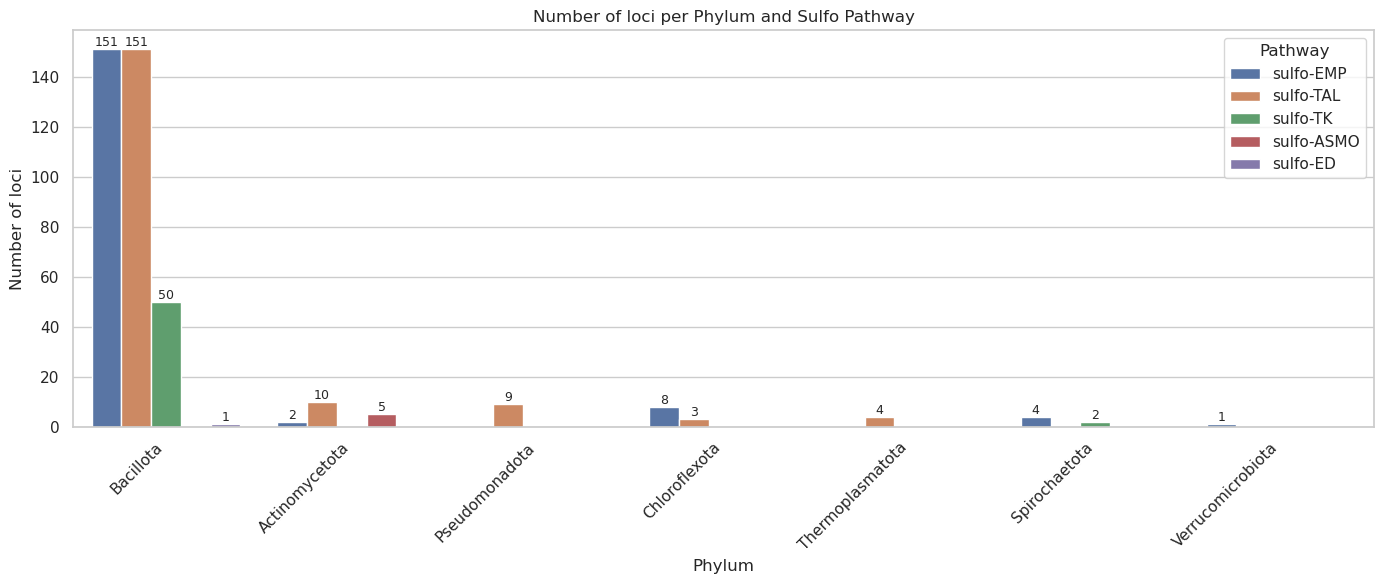

In [25]:
# Используем готовую таблицу со всеми count
plot_df = taxa_counts_sorted.copy()  # phylum, SQ_pathway, count

# Настройка графика
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Столбцы: x = phylum, y = count, цвет = путь
ax = sns.barplot(data=plot_df, x="phylum", y="count", hue="SQ_pathway", dodge=True)

# Подписи значений Y над столбцами (только если count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # текст подписи
            (p.get_x() + p.get_width() / 2., height),  # координаты: центр и вершина столбца
            ha='center', va='bottom', fontsize=9
        )

# Настройка подписей осей и заголовка
plt.xticks(rotation=45, ha="right")
plt.xlabel("Phylum")
plt.ylabel("Number of loci")
plt.title("Number of loci per Phylum and Sulfo Pathway")
plt.legend(title="Pathway")
plt.tight_layout()

# --- Сохраняем график ---
plt.savefig("sulfo_pathways_by_phylum.png", dpi=300)  # PNG с высоким разрешением
# plt.savefig("sulfo_pathways_by_phylum.pdf")  # альтернатива PDF

plt.show()

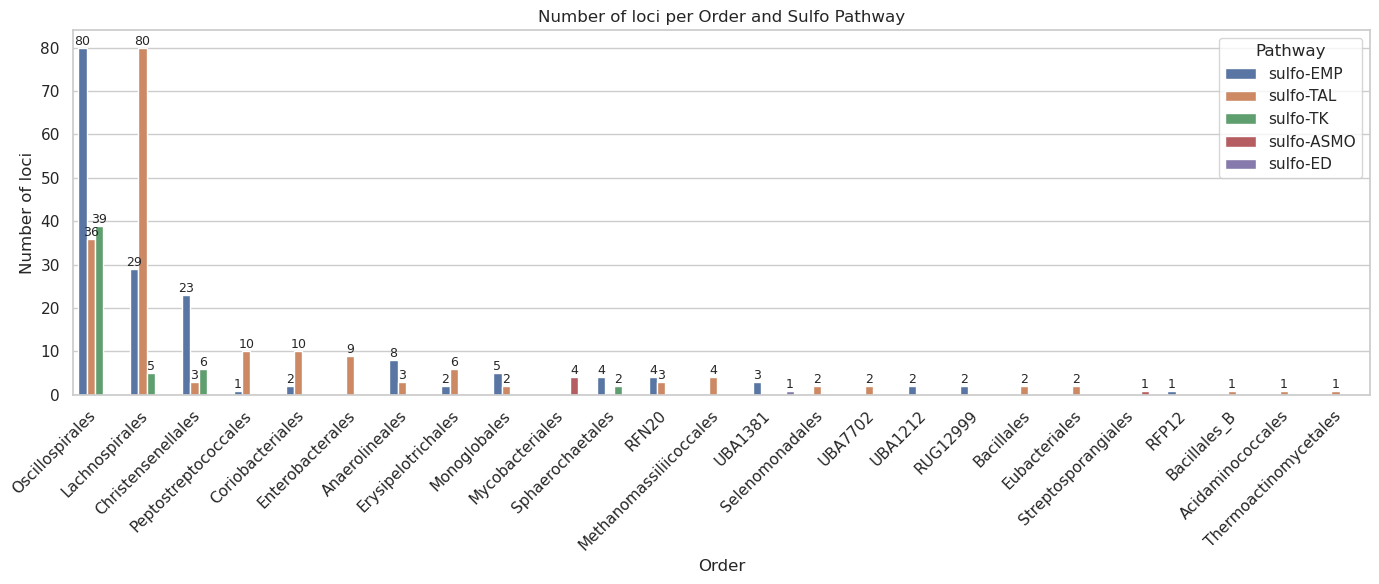

In [26]:
# Используем готовую таблицу со всеми count
plot_df = order_taxa_counts_sorted.copy()  # phylum, SQ_pathway, count

# Настройка графика
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Столбцы: x = phylum, y = count, цвет = путь
ax = sns.barplot(data=plot_df, x="order", y="count", hue="SQ_pathway", dodge=True)

# Подписи значений Y над столбцами (только если count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # текст подписи
            (p.get_x() + p.get_width() / 2., height),  # координаты: центр и вершина столбца
            ha='center', va='bottom', fontsize=9
        )

# Настройка подписей осей и заголовка
plt.xticks(rotation=45, ha="right")
plt.xlabel("Order")
plt.ylabel("Number of loci")
plt.title("Number of loci per Order and Sulfo Pathway")
plt.legend(title="Pathway")
plt.tight_layout()

# --- Сохраняем график ---
plt.savefig("sulfo_pathways_by_order.png", dpi=300)  # PNG с высоким разрешением
# plt.savefig("sulfo_pathways_by_phylum.pdf")  # альтернатива PDF

plt.show()